In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import missingno as msno
from scipy import stats
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import warnings

In [4]:
#Load dataset

nutrition_df = pd.read_csv("https://raw.githubusercontent.com/ekasaaa/analisis-dataset-gizi/refs/heads/main/nilai%20gizi.csv", delimiter=";")
nutrition_df.head()

,name,manufacturer,serving_size,energy_kcal,protein_g,carbohydrate_g,fat_g,sugar_g,sodium_mg,fiber_g,...,Natrium,Protein,Karbohidrat total,Energi,Lemak total,Serat pangan,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,Ikan sunu,asin,mentah,Tidak Diketahui,20.30 g,199.0,34.1,7.1,3.8,0.0,...,25.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,Soto pekalongan,masakan,Tidak Diketahui,1.30 g,94.0,3.0,5.1,6.8,0.0,0.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,Marie duo,Tidak Diketahui,1 g,15.0,1.0,14.0,3.5,5.0,85.0,1.0,...,6.00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,Kaparende,sayur,Tidak Diketahui,1.30 g,38.0,2.4,2.6,2.0,0.0,170.0,...,0.00,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,Kacang lebui / iris,Tidak Diketahui,3.60 g,346.0,16.5,66.6,1.5,0.0,17.0,37.3,...,0.00,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [5]:
#Menilai data nutrition_df

nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        1651 non-null   object 
 1   manufacturer                1651 non-null   object 
 2   serving_size                1651 non-null   object 
 3   energy_kcal                 1651 non-null   object 
 4   protein_g                   1651 non-null   object 
 5   carbohydrate_g              1651 non-null   object 
 6   fat_g                       1651 non-null   object 
 7   sugar_g                     1651 non-null   float64
 8   sodium_mg                   1651 non-null   float64
 9   fiber_g                     1651 non-null   float64
 10  energy_percentage_dv        1651 non-null   float64
 11  protein_percentage_dv       1651 non-null   float64
 12  carbohydrate_percentage_dv  1651 non-null   float64
 13  fat_percentage_dv           1651 

In [6]:
#Mengecek missing values pada dataset nutrition_df

nutrition_df.isna().sum()

name                             0
manufacturer                     0
serving_size                     0
energy_kcal                      0
protein_g                        0
carbohydrate_g                   0
fat_g                            0
sugar_g                          0
sodium_mg                        0
fiber_g                          0
energy_percentage_dv             0
protein_percentage_dv            0
carbohydrate_percentage_dv       0
fat_percentage_dv                0
sodium_percentage_dv             0
Lemak jenuh                      0
Natrium                          0
Protein                          0
Karbohidrat total                0
Energi                           0
Lemak total                      0
Serat pangan                     0
Unnamed: 22                   1196
Unnamed: 23                   1586
Unnamed: 24                   1641
Unnamed: 25                   1649
dtype: int64

In [7]:
#Mengecek duplikasi tabel nutrition_df

print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


In [8]:
#Mengecek menggunakan method describe

nutrition_df.describe()

,sugar_g,sodium_mg,fiber_g,energy_percentage_dv,protein_percentage_dv,carbohydrate_percentage_dv,fat_percentage_dv,sodium_percentage_dv,Lemak jenuh,Natrium,Protein,Karbohidrat total,Energi,Lemak total,Serat pangan,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
count,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,455.0,65.0,10.0,2.0
mean,5.924906,99.068565,23.429085,12.353998,11.175542,10.120218,11.795845,8.384155,3.215530,4.300485,4.094482,2.468280,3.687462,5.227135,1.013931,0.0,0.0,0.0,0.0
std,13.792322,407.541251,106.819370,51.215859,32.562132,11.118718,18.874163,27.627000,10.961959,14.592509,12.379304,5.861247,7.990628,14.224772,6.354129,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.000000,0.000000,0.000000,2.200000,1.670000,3.330000,1.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.400000,0.000000,0.700000,5.580000,5.000000,6.460000,5.220000,0.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,6.000000,34.000000,4.000000,12.490000,13.330000,14.000000,14.930000,6.000000,0.270000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,0.0,0.0,0.0,0.0
max,201.000000,11998.000000,1724.000000,1068.000000,1081.000000,123.830000,182.090000,799.870000,225.000000,136.000000,132.000000,57.000000,80.000000,183.000000,147.000000,0.0,0.0,0.0,0.0


In [9]:
#CLEANING DATA

#mengubah tulisan "tidak diketahui" menjadi NaN agar bisa diproses
nutrition_df['serving_size'] = nutrition_df['serving_size'].replace('tidak diketahui', np.nan)

#Ambil angkanya saja (membuang 'g', 'ml', dll)
#Regex ini akan mengambil angka desimal maupun bulat
nutrition_df['serving_size'] = nutrition_df['serving_size'].str.extract('(\d+\.?\d*)').astype(float)

#Isi data yang kosong (NaN) tadi dengan nilai tengah (Median)
median_serving = nutrition_df['serving_size'].median()
nutrition_df['serving_size'] = nutrition_df['serving_size'].fillna(median_serving)

print("Tipe data serving_size sekarang:", nutrition_df['serving_size'].dtype)

Tipe data serving_size sekarang: float64


In [10]:
#cek
nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        1651 non-null   object 
 1   manufacturer                1651 non-null   object 
 2   serving_size                1651 non-null   float64
 3   energy_kcal                 1651 non-null   object 
 4   protein_g                   1651 non-null   object 
 5   carbohydrate_g              1651 non-null   object 
 6   fat_g                       1651 non-null   object 
 7   sugar_g                     1651 non-null   float64
 8   sodium_mg                   1651 non-null   float64
 9   fiber_g                     1651 non-null   float64
 10  energy_percentage_dv        1651 non-null   float64
 11  protein_percentage_dv       1651 non-null   float64
 12  carbohydrate_percentage_dv  1651 non-null   float64
 13  fat_percentage_dv           1651 

In [11]:
#Menghapus kolom Unnamed yang tidak diperlukan

nutrition_df.drop(nutrition_df.columns[nutrition_df.columns.str.contains('unnamed', case=False)], axis=1, inplace=True)

In [12]:
#cek
nutrition_df.isna().sum()

name                          0
manufacturer                  0
serving_size                  0
energy_kcal                   0
protein_g                     0
carbohydrate_g                0
fat_g                         0
sugar_g                       0
sodium_mg                     0
fiber_g                       0
energy_percentage_dv          0
protein_percentage_dv         0
carbohydrate_percentage_dv    0
fat_percentage_dv             0
sodium_percentage_dv          0
Lemak jenuh                   0
Natrium                       0
Protein                       0
Karbohidrat total             0
Energi                        0
Lemak total                   0
Serat pangan                  0
dtype: int64

In [13]:
#Mengecek duplikasi tabel nutrition_df

print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


In [14]:
#Mengecek menggunakan method describe

nutrition_df.describe()

,serving_size,sugar_g,sodium_mg,fiber_g,energy_percentage_dv,protein_percentage_dv,carbohydrate_percentage_dv,fat_percentage_dv,sodium_percentage_dv,Lemak jenuh,Natrium,Protein,Karbohidrat total,Energi,Lemak total,Serat pangan
count,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000
mean,3.570412,5.924906,99.068565,23.429085,12.353998,11.175542,10.120218,11.795845,8.384155,3.215530,4.300485,4.094482,2.468280,3.687462,5.227135,1.013931
std,16.043425,13.792322,407.541251,106.819370,51.215859,32.562132,11.118718,18.874163,27.627000,10.961959,14.592509,12.379304,5.861247,7.990628,14.224772,6.354129
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,2.200000,1.670000,3.330000,1.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.800000,0.400000,0.000000,0.700000,5.580000,5.000000,6.460000,5.220000,0.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.700000,6.000000,34.000000,4.000000,12.490000,13.330000,14.000000,14.930000,6.000000,0.270000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000
max,591.000000,201.000000,11998.000000,1724.000000,1068.000000,1081.000000,123.830000,182.090000,799.870000,225.000000,136.000000,132.000000,57.000000,80.000000,183.000000,147.000000


In [15]:
#ubah tipe data kolom nutrisi menjadi numerik (float) dengan menghapus karakter non-numerik

cols = ['energy_kcal', 'protein_g', 'fat_g', 'carbohydrate_g', 'sugar_g']

for col in cols:
    nutrition_df[col] = nutrition_df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)
    nutrition_df[col] = pd.to_numeric(nutrition_df[col], errors='coerce')

In [16]:
#cek
nutrition_df.isna().sum()

name                           0
manufacturer                   0
serving_size                   0
energy_kcal                   65
protein_g                     10
carbohydrate_g                 2
fat_g                          0
sugar_g                        0
sodium_mg                      0
fiber_g                        0
energy_percentage_dv           0
protein_percentage_dv          0
carbohydrate_percentage_dv     0
fat_percentage_dv              0
sodium_percentage_dv           0
Lemak jenuh                    0
Natrium                        0
Protein                        0
Karbohidrat total              0
Energi                         0
Lemak total                    0
Serat pangan                   0
dtype: int64

In [17]:
#drop baris yang memiliki nilai NaN pada kolom protein_g dan carbohydrate_g karena kedua fitur ini penting untuk analisis lebih lanjut

nutrition_df = nutrition_df.dropna(subset=['protein_g', 'carbohydrate_g'])

In [18]:
#isi data yang kosong (NaN) pada kolom energy_kcal dengan nilai tengah (Median) karena fitur ini juga penting untuk analisis lebih lanjut

nutrition_df['energy_kcal'].fillna(nutrition_df['energy_kcal'].median(), inplace=True)

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4848\3095917187.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nutrition_df['energy_kcal'].fillna(nutrition_df['energy_kcal'].median(), inplace=True)


In [19]:
#cek
nutrition_df.isna().sum()

name                          0
manufacturer                  0
serving_size                  0
energy_kcal                   0
protein_g                     0
carbohydrate_g                0
fat_g                         0
sugar_g                       0
sodium_mg                     0
fiber_g                       0
energy_percentage_dv          0
protein_percentage_dv         0
carbohydrate_percentage_dv    0
fat_percentage_dv             0
sodium_percentage_dv          0
Lemak jenuh                   0
Natrium                       0
Protein                       0
Karbohidrat total             0
Energi                        0
Lemak total                   0
Serat pangan                  0
dtype: int64

In [20]:
#Mengecek duplikasi tabel nutrition_df

print("Jumlah duplikasi: ", nutrition_df.duplicated().sum())

Jumlah duplikasi:  0


In [21]:
nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1641 entries, 0 to 1650
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        1641 non-null   object 
 1   manufacturer                1641 non-null   object 
 2   serving_size                1641 non-null   float64
 3   energy_kcal                 1641 non-null   float64
 4   protein_g                   1641 non-null   float64
 5   carbohydrate_g              1641 non-null   float64
 6   fat_g                       1641 non-null   float64
 7   sugar_g                     1641 non-null   float64
 8   sodium_mg                   1641 non-null   float64
 9   fiber_g                     1641 non-null   float64
 10  energy_percentage_dv        1641 non-null   float64
 11  protein_percentage_dv       1641 non-null   float64
 12  carbohydrate_percentage_dv  1641 non-null   float64
 13  fat_percentage_dv           1641 non-n

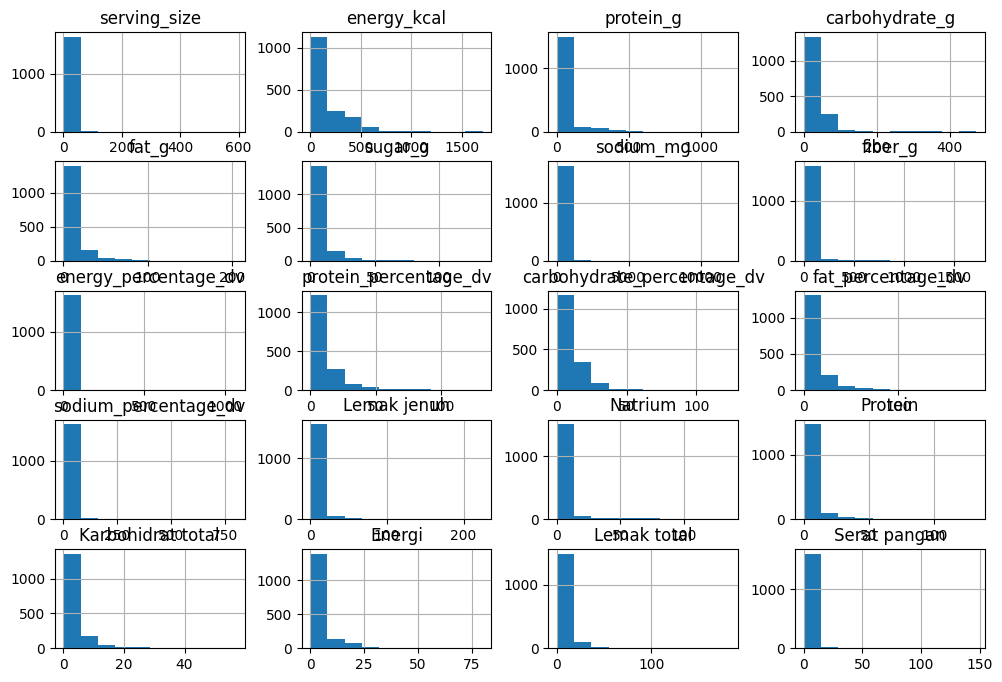

In [22]:
#mengecek distribusi data dengan histogram
nutrition_df.hist(figsize=(12,8))
plt.show()

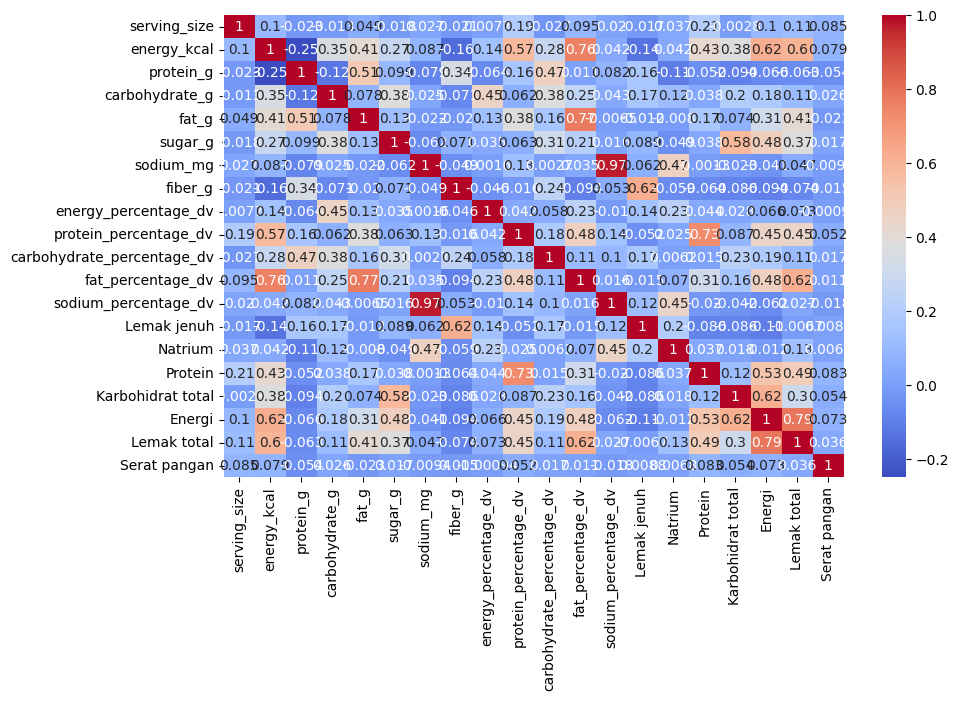

In [23]:
plt.figure(figsize=(10,6))
numeric_df = nutrition_df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [24]:
#mengambil fitur yang akan digunakan untuk analisis

fitur = [
    'energy_kcal',
    'protein_g',
    'fat_g',
    'carbohydrate_g',
    'sugar_g'
]

X = nutrition_df[fitur]

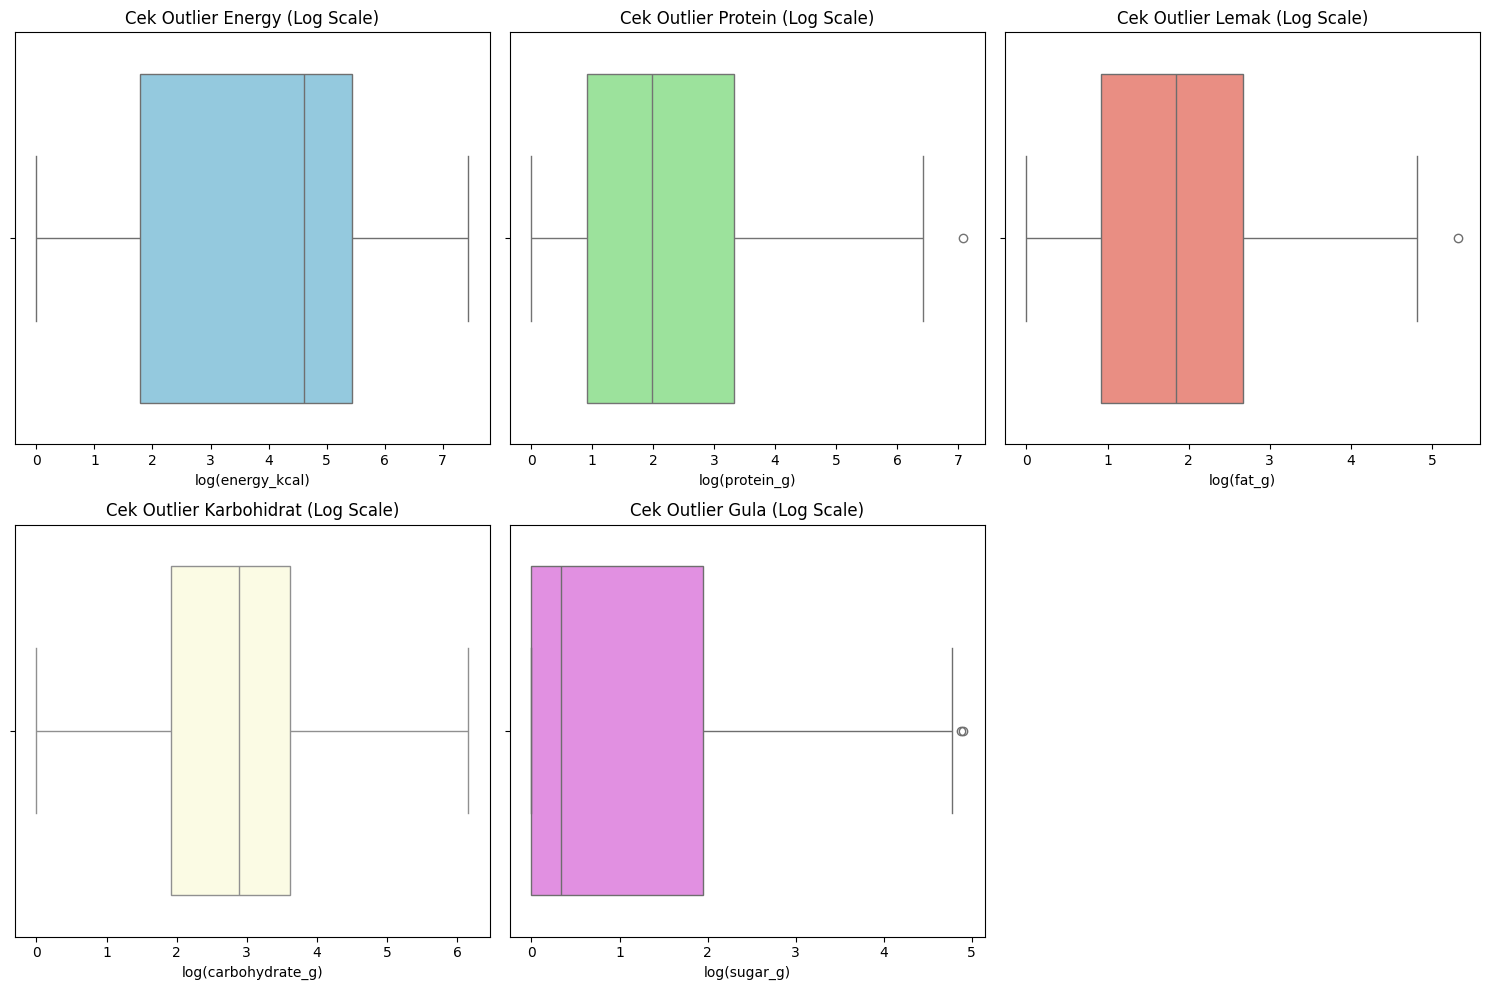

In [25]:
#mengecek outlier

plt.figure(figsize=(15, 10))

# 1. Energy
plt.subplot(2, 3, 1)
sns.boxplot(x=np.log1p(nutrition_df['energy_kcal']), color='skyblue')
plt.title('Cek Outlier Energy (Log Scale)')
plt.xlabel('log(energy_kcal)')

# 2. Protein
plt.subplot(2, 3, 2)
sns.boxplot(x=np.log1p(nutrition_df['protein_g']), color='lightgreen')
plt.title('Cek Outlier Protein (Log Scale)')
plt.xlabel('log(protein_g)')

# 3. Lemak
plt.subplot(2, 3, 3)
sns.boxplot(x=np.log1p(nutrition_df['fat_g']), color='salmon')
plt.title('Cek Outlier Lemak (Log Scale)')
plt.xlabel('log(fat_g)')

# 4. Karbohidrat
plt.subplot(2, 3, 4)
sns.boxplot(x=np.log1p(nutrition_df['carbohydrate_g']), color='lightyellow')
plt.title('Cek Outlier Karbohidrat (Log Scale)')
plt.xlabel('log(carbohydrate_g)')

# 5. Gula
plt.subplot(2, 3, 5)
sns.boxplot(x=np.log1p(nutrition_df['sugar_g']), color='violet')
plt.title('Cek Outlier Gula (Log Scale)')
plt.xlabel('log(sugar_g)')

plt.tight_layout()
plt.show()

In [26]:
#menghitung jumlah outlier menggunakan metode IQR

def cek_outlier_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outlier)} outlier")

for col in ['energy_kcal', 'protein_g', 'fat_g', 'carbohydrate_g', 'sugar_g']:
    cek_outlier_iqr(nutrition_df, col)

energy_kcal: 51 outlier
protein_g: 258 outlier
fat_g: 139 outlier
carbohydrate_g: 91 outlier
sugar_g: 186 outlier


In [27]:
#SCALING DATA

# kolom yang mau di-scaling
cols = ['energy_kcal', 'protein_g', 'fat_g', 'carbohydrate_g', 'sugar_g']


# inisialisasi scaler
scaler = MinMaxScaler()


# lakukan scaling
nutrition_df[cols] = scaler.fit_transform(nutrition_df[cols])

kolom_final = ['name'] + cols
nutrition_output = nutrition_df[kolom_final]

print("Data setelah Scaling (MinMaxScaler):")
display(nutrition_output.head())

Data setelah Scaling (MinMaxScaler):


,name,energy_kcal,protein_g,fat_g,carbohydrate_g,sugar_g
0,Ikan sunu,0.058480,0.016917,0.166341,0.420719,0.052985
1,Soto pekalongan,0.000760,0.078333,0.024878,0.006342,0.050746
2,Marie duo,0.008772,0.000833,0.017073,0.029598,0.037313
3,Kaparende,0.000760,0.031667,0.012683,0.005074,0.014925
4,Kacang lebui / iris,0.202339,0.013750,0.007317,0.140803,0.000000


In [28]:
#Menyimpan dataset yang sudah bersih dan discale ke file CSV baru
nutrition_output.to_csv('dataset_nilai_gizi_cleaned_scaled(revisi2).csv', index=False,sep=',', decimal='.')

print("Selamat! Dataset sudah berhasil dibersihkan, di-scale, dan disimpan.")
print("File tersimpan dengan nama: dataset_nilai_gizi_cleaned_scaled.csv")

Selamat! Dataset sudah berhasil dibersihkan, di-scale, dan disimpan.
File tersimpan dengan nama: dataset_nilai_gizi_cleaned_scaled.csv
